In [1]:
# This code aim to perform a bootstrap to municipality level timeseries
import numpy as np
import pandas as pd

In [3]:
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/aesop_with_MEM_24_03_2026.parquet')


In [4]:
df = df[df.year_week <= '2025-32']

In [5]:
df = df[df.co_ibge != 510183]

In [6]:
df.columns

Index(['co_uf', 'nm_uf', 'nm_municipio', 'co_ibge', 'epiyear', 'epiweek',
       'year_week', 'atend_totais', 'atend_ivas',
       'mem_surge_01_correct_with_consec', 'warning_final_mem_surge_01'],
      dtype='object')

# Aqui começa o codigo

In [7]:
def insert_outbreak(series, start_week, duration, k, lognorm_mean=0, lognorm_sd=0.5, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    series = series.copy()
    n = len(series)

    sigma = np.std(series)

    # total outbreak size
    outbreak_size = rng.poisson(k * sigma)

    if outbreak_size == 0:
        return series, {"start": start_week, "end": start_week, "size": 0}

    # lognormal temporal distribution
    times = rng.lognormal(lognorm_mean, lognorm_sd, outbreak_size)

    # scale to chosen duration
    offsets = np.floor((times / times.max()) * (duration-1)).astype(int)

    outbreak_weeks = start_week + offsets
    outbreak_weeks = outbreak_weeks[outbreak_weeks < n]

    for w in outbreak_weeks:
        series[w] += 1

    return series, {
        "start": start_week,
        "end": int(start_week + duration),
        "size": int(outbreak_size),
        'k':k,
        "duration": duration
    }

In [8]:
def generate_replicate(series, max_outbreaks=2, min_gap=4, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    n = len(series)
    new_series = series.copy()

    # number of outbreaks
    K = rng.integers(1, max_outbreaks + 1)

    outbreaks = []

    attempts = 0
    max_attempts = 200

    while len(outbreaks) < K and attempts < max_attempts:

        start = rng.integers(415, n-10) # aqui muda as o inicio da semana
        duration = rng.integers(4, 11)
        end = start + duration

        valid = True

        # check overlap + minimum gap
        for ob in outbreaks:

            existing_start = ob["start"]
            existing_end = ob["end"]

            if not (end + min_gap < existing_start or start > existing_end + min_gap):
                valid = False
                break

        if valid:

            k = rng.uniform(2, 10)

            new_series, info = insert_outbreak(
                new_series,
                start_week=start,
                duration=duration,
                k=k,
                rng=rng
            )

            outbreaks.append(info)

        attempts += 1

    return new_series, outbreaks

# Rodar para todos os municipios

In [16]:
dfs_muni_repl = []

dfs_out_meta = []


for code in df.co_ibge.unique():

    print(code)

    set_muni = df[df.co_ibge == code].reset_index()[['co_ibge','year_week', 'atend_ivas','mem_surge_01_correct_with_consec','warning_final_mem_surge_01']]


    replicates = []
    outbreak_metadata = []

    baseline = set_muni["atend_ivas"].values

    rng = np.random.default_rng(42)

    for r in range(32): # numero de replicas
        new_series, outbreaks = generate_replicate(baseline, rng=rng)

        replicates.append(new_series)
        outbreak_metadata.append(outbreaks)

    # Format replicates dataframe
    replicates_df = pd.DataFrame(replicates).T
    replicates_df.columns = [f"replicate_{i}" for i in range(len(replicates))]

    # Combine set_muni and replicates_df
    #set_muni_combined = pd.concat([set_muni, replicates_df], axis=1).reset_index() it doesnt work
    set_muni_combined = replicates_df.assign(co_ibge = set_muni.co_ibge.astype(int),
                                     year_week = set_muni.year_week,
                                     atend_ivas = set_muni.atend_ivas.astype(int), 
                                     mem_surge_01_correct_with_consec = set_muni.mem_surge_01_correct_with_consec.astype(int),
                                     warning_final_mem_surge_01 = set_muni.warning_final_mem_surge_01.astype(int))


    # Format outbreak metadata
    rows = [
        {**outbreak, "replicate": i}
        for i, replicate in enumerate(outbreak_metadata)
        for outbreak in replicate
            ]

    outbreak_metadata_final = pd.DataFrame(rows)
    outbreak_metadata_final = outbreak_metadata_final.assign(co_ibge = set_muni_combined.co_ibge.iloc[0])

    mapping = set_muni_combined.reset_index().set_index('index')['year_week']

    outbreak_metadata_final['start_year_week'] = outbreak_metadata_final['start'].map(mapping)
    outbreak_metadata_final['end_year_week'] = outbreak_metadata_final['end'].map(mapping)

    dfs_muni_repl.append(set_muni_combined)

    dfs_out_meta.append(outbreak_metadata_final)


110001
110002
110005
110007
110008
110009
110010
110011
110013
110014
110015
110018
110020
110025
110026
110028
110029
110030
110032
110033
110034
110037
110040
110045
110050
110060
110080
110090
110092
110094
110100
110110
110120
110130
110143
110145
110146
110147
110148
110149
110150
110155
110160
110170
110180
120005
120010
120013
120017
120020
120025
120030
120032
120033
120034
120035
120038
120039
120040
120042
120043
120045
120050
120060
120070
120080
130002
130006
130008
130010
130014
130020
130030
130040
130050
130060
130063
130068
130070
130080
130083
130090
130100
130110
130115
130120
130130
130150
130160
130165
130170
130180
130185
130190
130200
130210
130220
130230
130240
130250
130255
130260
130270
130280
130290
130300
130310
130320
130330
130340
130350
130353
130356
130360
130370
130380
130390
130395
130400
130406
130410
130420
130423
130426
130430
130440
140002
140005
140010
140015
140017
140020
140023
140028
140030
140040
140045
140047
140050
140060
140070
150010
150013

In [17]:
from pathlib import Path
from datetime import datetime

# ============================================================
# Save output
# ============================================================

DATA_PATH = "/opt/storage/shared/aesop/aesop_shared/ensamble_modelling"
Path(DATA_PATH).mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d")

# ---- Main synthetic data ----
final_sintetic = pd.concat(dfs_muni_repl, ignore_index=True)

out_file = Path(DATA_PATH) / f"sintetic_outbreak_{timestamp}.parquet"

final_sintetic.to_parquet(out_file, compression="zstd")


# ---- Outbreak metadata ----
final_out_meta = pd.concat(dfs_out_meta, ignore_index=True)

out_file_meta = Path(DATA_PATH) / f"sintetic_outbreak_metadata_{timestamp}.parquet"

final_out_meta.to_parquet(out_file_meta, compression="zstd")

In [18]:
final_sintetic.columns

Index(['replicate_0', 'replicate_1', 'replicate_2', 'replicate_3',
       'replicate_4', 'replicate_5', 'replicate_6', 'replicate_7',
       'replicate_8', 'replicate_9', 'replicate_10', 'replicate_11',
       'replicate_12', 'replicate_13', 'replicate_14', 'replicate_15',
       'replicate_16', 'replicate_17', 'replicate_18', 'replicate_19',
       'replicate_20', 'replicate_21', 'replicate_22', 'replicate_23',
       'replicate_24', 'replicate_25', 'replicate_26', 'replicate_27',
       'replicate_28', 'replicate_29', 'replicate_30', 'replicate_31',
       'co_ibge', 'year_week', 'atend_ivas',
       'mem_surge_01_correct_with_consec', 'warning_final_mem_surge_01'],
      dtype='object')

In [19]:
#final_out_meta[final_out_meta['size'] == 0]#.min()#.co_ibge#.nunique()
final_sintetic

,replicate_0,replicate_1,replicate_2,replicate_3,replicate_4,replicate_5,replicate_6,replicate_7,replicate_8,replicate_9,...,replicate_27,replicate_28,replicate_29,replicate_30,replicate_31,co_ibge,year_week,atend_ivas,mem_surge_01_correct_with_consec,warning_final_mem_surge_01
0,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,110001,2017-01,9,0,0
1,16,16,16,16,16,16,16,16,16,16,...,16,16,16,16,16,110001,2017-02,16,0,0
2,15,15,15,15,15,15,15,15,15,15,...,15,15,15,15,15,110001,2017-03,15,0,0
3,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,110001,2017-04,17,0,0
4,11,11,11,11,11,11,11,11,11,11,...,11,11,11,11,11,110001,2017-05,11,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2500925,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,315390,2025-28,0,0,0
2500926,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,315390,2025-29,0,0,0
2500927,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,315390,2025-30,0,0,0
2500928,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,315390,2025-31,0,0,0


# Plot to check

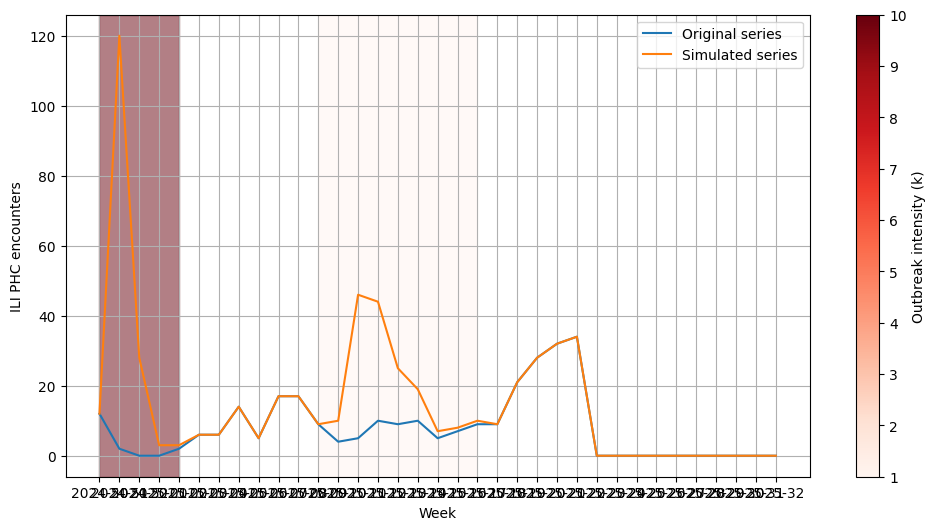

In [20]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl # Added for the new colormap syntax

rep = 3

set_muni_combined = set_muni_combined[set_muni_combined.year_week >= '2024-50']

plt.figure(figsize=(12, 6))

# Plot original and simulated series
plt.plot(set_muni_combined["year_week"],
         set_muni_combined["atend_ivas"],
         label="Original series")

plt.plot(set_muni_combined["year_week"],
         set_muni_combined.replicate_3,
         #replicates_df[418:][f"replicate_{rep}"],
         label="Simulated series")

# Extract intensity values
k_values = [ob["k"] for ob in outbreak_metadata[rep]]

# Normalize intensity for color mapping
# (Added a fallback [0, 1] if k_values is empty to prevent errors)
vmin = min(k_values) if k_values else 0
vmax = max(k_values) if k_values else 1
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# --- FIX 1: Modern Colormap Syntax ---
cmap = mpl.colormaps["Reds"]

# Plot outbreaks
for outbreak in outbreak_metadata[rep]:
    start = outbreak["start"]
    end = outbreak["end"]
    k = outbreak["k"]

    color = cmap(norm(k))

    plt.axvspan(set_muni["year_week"][start -1], #.iloc,
                set_muni["year_week"][end -1],
                color=color,
                alpha=0.5)

# Colorbar legend
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# --- FIX 2: Explicitly pass the Axes to the colorbar ---
norm = mpl.colors.Normalize(vmin=1, vmax=10)  # ← set limits here
sm = mpl.cm.ScalarMappable(cmap='Reds', norm=norm)

cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Outbreak intensity (k)")

plt.xlabel("Week")
plt.ylabel("ILI PHC encounters")

plt.legend()
plt.grid(True)

plt.show()